In [1]:
from pest import FitsDataset

ds = FitsDataset("/urz/gpuscratch/its/doserbd/data/SKIRT_synthetic_images/fits")
print(len(ds))

58033


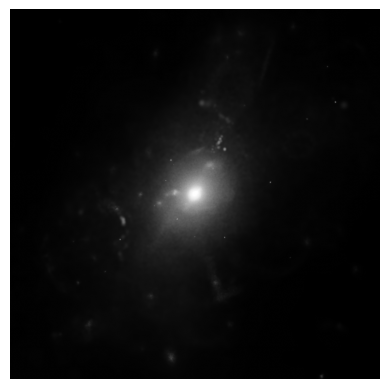

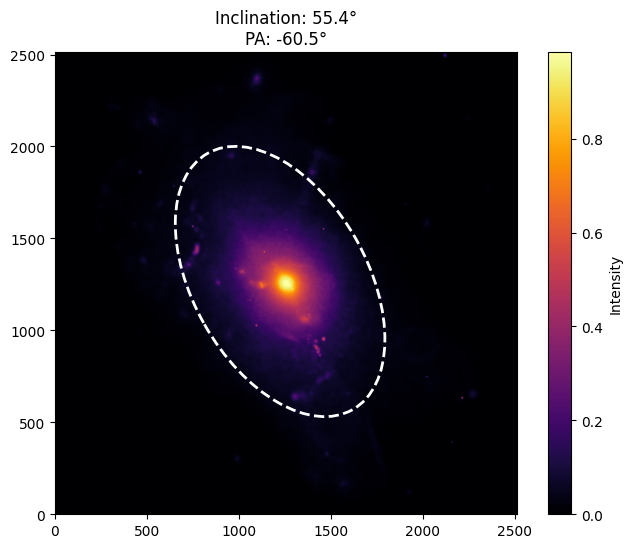

In [10]:
import matplotlib.pyplot as plt
from pest import estimate_geometry_weighted, visualize_results
import numpy as np

plt.rcParams["text.usetex"] = False

image = ds[0].transpose(1, 2, 0)
gray = np.mean(image, axis=-1)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

stats = estimate_geometry_weighted(gray)
visualize_results(stats)


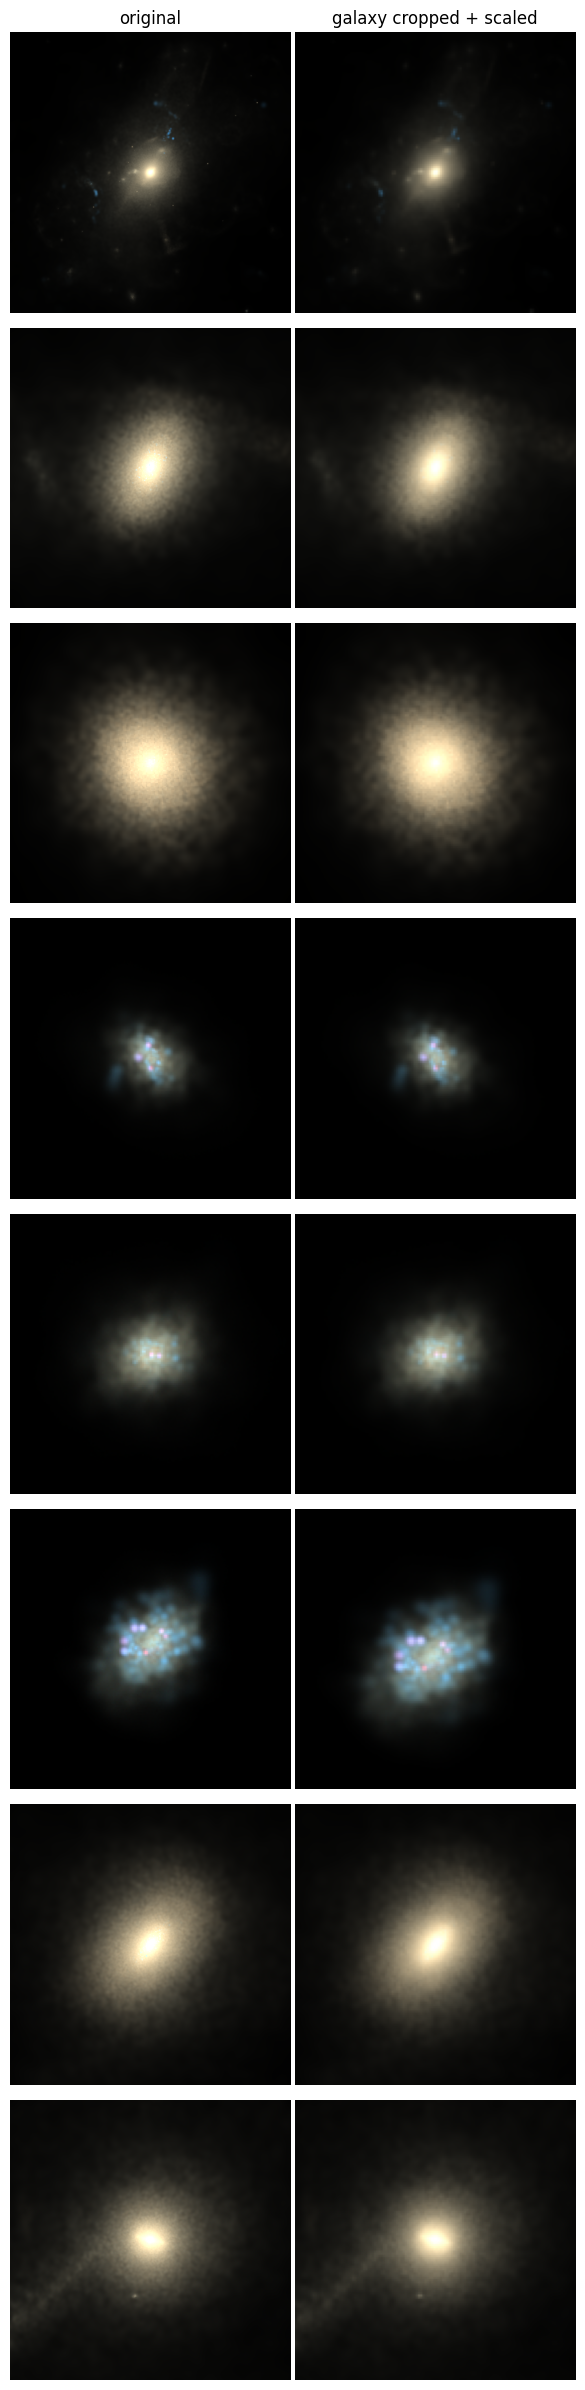

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import resize

plt.rcParams["text.usetex"] = False

TARGET = 128


def crop_and_scale(img_hwc, target=TARGET):
    """Crop to the galaxy bounding box and resize to target x target."""
    mask = np.any(img_hwc > 0, axis=-1)
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any():
        return resize(img_hwc, (target, target), anti_aliasing=True)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img_hwc[rmin : rmax + 1, cmin : cmax + 1]
    return resize(cropped, (target, target), anti_aliasing=True)


n = min(8, len(ds))
fig, axes = plt.subplots(n, 2, figsize=(6, n * 3))

for i in range(n):
    img = ds[i]
    if img is None:
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        continue
    original = img.transpose(1, 2, 0)
    scaled = crop_and_scale(original)
    axes[i, 0].imshow(original)
    axes[i, 0].set_title("original" if i == 0 else "")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(scaled)
    axes[i, 1].set_title("galaxy cropped + scaled" if i == 0 else "")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()
